# Basic setup

In [2]:
# Importing libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# from sklearn.preprocessing import StandardScaler

# Gaussian distribution

## Population

<Axes: ylabel='Count'>

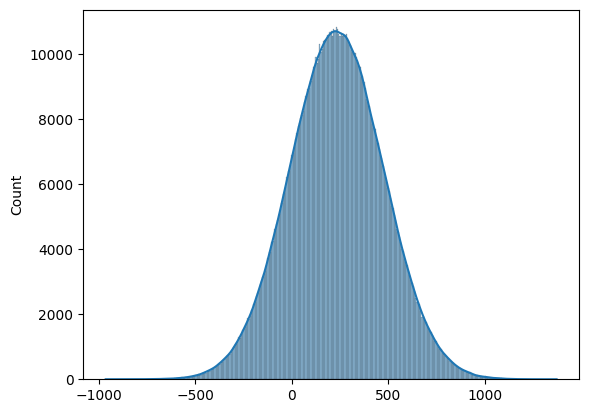

In [3]:
# Creating a population with normal distribution

rng = np.random.default_rng()
normal  =rng.normal(loc=232, scale=243, size=1000000)
sns.histplot(normal, kde=True)

In [4]:
# Calculating the mean and standard deviation manually

manual_mean = normal.sum() / len(normal)
print(f'Manual mean: {manual_mean:,.2f}')
manual_variance = float(np.sum((normal - manual_mean) ** 2) ) / len(normal)
print(f'Manual variance: {manual_variance:,.2f}')
manual_std = np.sqrt(manual_variance)
print(f'Manual std: {manual_std:,.2f}')


Manual mean: 232.13
Manual variance: 59,150.36
Manual std: 243.21


In [5]:
# Calculating the mean and standard deviation with formulas

normal_mean = normal.mean()
print(f'Normal mean: {normal_mean:,.2f}')
normal_variance = normal.var()
print(f'Normal variance: {normal_variance:,.2f}')
normal_std = normal.std()
print(f'Normal std: {normal_std:,.2f}')


Normal mean: 232.13
Normal variance: 59,150.36
Normal std: 243.21


## Standardization Z scores

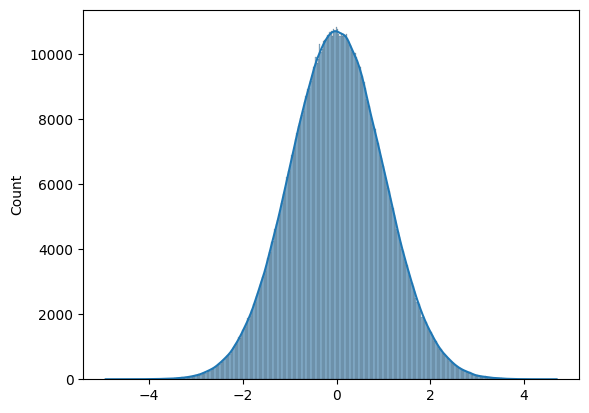

Mean of standardized data: 0.00


In [6]:
# Normalization
normal_normalized = (normal - normal_mean) / normal_std
sns.histplot(normal_normalized, kde=True)
plt.show()

print(f'Mean of standardized data: {normal_normalized.mean():,.2f}')

In [7]:
# Combining the two datasets: normal and normalized

all_normal = pd.DataFrame({'Normal': normal, 'Normal_normalized': normal_normalized})

all_normal.head()

,Normal,Normal_normalized
0,-165.477980,-1.634864
1,251.837931,0.081013
2,373.642967,0.581839
3,81.679082,-0.618629
4,-188.236243,-1.728439


## Sampling


Manual calculations:

Sample mean: 230.75
Sample variance: 61,075.13
Sample standard deviation: 247.13
Sample Standard Error of the Mean: 7.82

Formula calculations:

Sample mean: 230.75
Sample variance: 61,075.13
Sample standard deviation: 247.13
Sample Standard Error of the Mean: 7.82


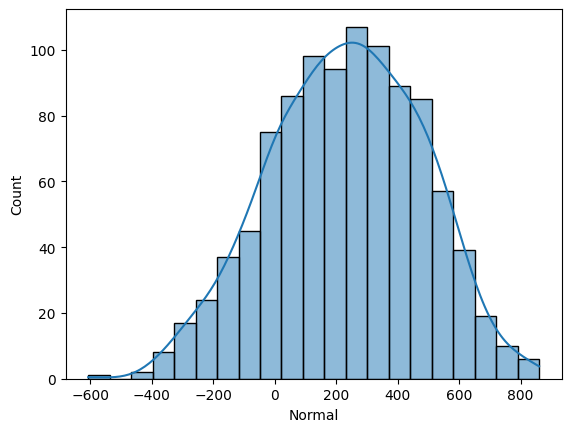

In [8]:
sample = all_normal['Normal'].sample(1000)
sns.histplot(sample, kde=True)

# Manual calculations
print('\nManual calculations:\n')
sample_mean = float(np.sum(sample)) / len(sample)
print(f'Sample mean: {sample_mean:,.2f}')

sample_variance = float(np.sum((sample - sample_mean)**2)) / (len(sample)-1)
print(f'Sample variance: {sample_variance:,.2f}')

sample_std = np.sqrt(sample_variance)
print(f'Sample standard deviation: {sample_std:,.2f}')

# Standard error
sample_sem = sample_std / np.sqrt(len(sample))
print(f'Sample Standard Error of the Mean: {sample_sem:,.2f}')

# Formula calculations
print('\nFormula calculations:\n')
for_sample_mean = sample.mean()
print(f'Sample mean: {for_sample_mean:,.2f}')

for_sample_variance = sample.var(ddof=1)
print(f'Sample variance: {for_sample_variance:,.2f}')

for_sample_std = np.std(sample, ddof=1)
print(f'Sample standard deviation: {for_sample_std:,.2f}')

for_sample_sem = stats.sem(sample)
print(f'Sample Standard Error of the Mean: {for_sample_sem:,.2f}')


Sample mean: 232.53


<Axes: ylabel='Count'>

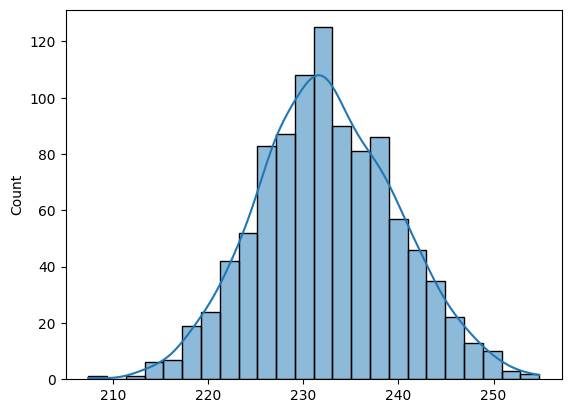

In [9]:
# Ongoing sampling

sample_means = []
for i in range(1000):
    sample_mean = all_normal['Normal'].sample(1000).mean()
    sample_means.append(sample_mean)

sample_means_np = np.array(sample_means)
print(f'Sample mean: {sample_means_np.mean():,.2f}')

sns.histplot(sample_means_np, kde=True)

<Axes: ylabel='Count'>

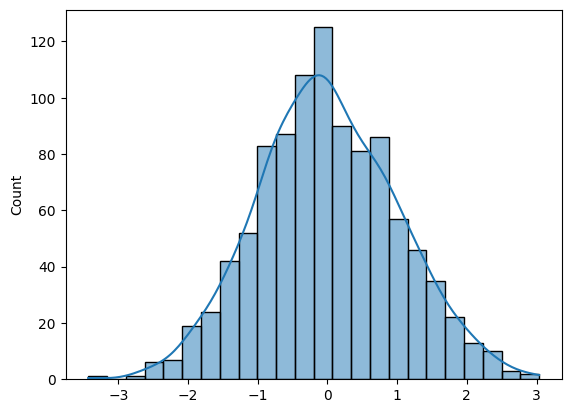

In [10]:
# Standardizing the sample means does not bring any specific value
standard_sample_means = stats.zscore(sample_means_np) #
# CDF
sns.histplot(standard_sample_means, kde=True, cumulative=False)

# Exponential distribution

<Axes: ylabel='Count'>

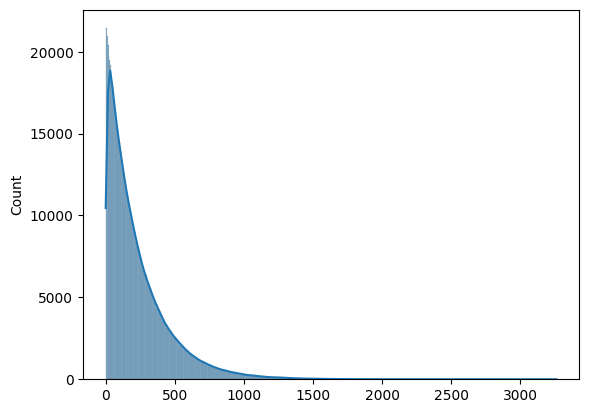

In [11]:
# Creating a population with exponential distribution

rng = np.random.default_rng()
expo = rng.exponential(scale=232, size=1000000)
sns.histplot(expo, kde=True)

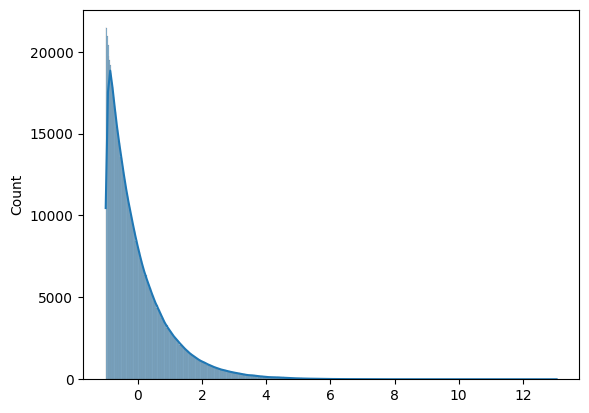

In [12]:
expo_zscore = stats.zscore(expo)
sns.histplot(expo_zscore, kde=True)

all_expo = pd.DataFrame({'Exponential': expo, 'Exponential_zscore': expo_zscore})

## Central Limit Theorem

<Axes: ylabel='Count'>

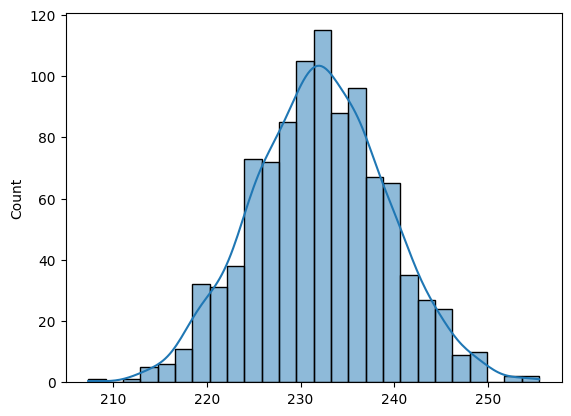

In [13]:
expo_means = []
for i in range(1000):
    expo_mean = all_expo['Exponential'].sample(1000).mean()
    expo_means.append(expo_mean)

sns.histplot(expo_means, kde=True)

# Hypothesis testing

Sample mean: 230.75


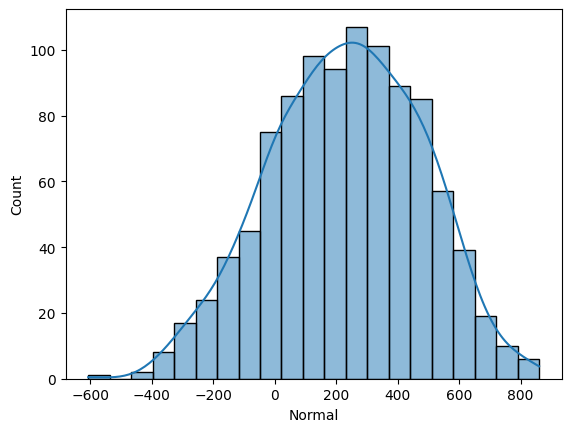

In [15]:
small_sample = all_normal['Normal'].sample(1000)
sns.histplot(sample, kde=True)
print(f'Sample mean: {sample.mean():,.2f}')

In [53]:
# Calculating the standard error

sample_sem = small_sample.std(ddof=1) / np.sqrt(len(small_sample))
print(f'The sample mean is {small_sample.mean():,.2f}')
print(f'The standard error of the mean is: {sample_sem:,.2f}')

The sample mean is 212.62
The standard error of the mean is: 7.74


In [55]:
# Confidence interval
# 1.96 is the 95% confidence interval (critical value)

margin_of_error = 1.96 * sample_sem
confidence_interval_upper = small_sample.mean() + margin_of_error
confidence_interval_lower = small_sample.mean() - margin_of_error
print(f'The confidence interval is between: {confidence_interval_lower:,.2f} and {confidence_interval_upper:,.2f}')

The confidence interval is between: 197.45 and 227.79


In [38]:
# Hypothesis testing

# Z statistic
hyp_mean = 180 #H0

z_statistic = (small_sample.mean() - hyp_mean) / sample_sem
p_value = 100 * stats.norm.sf(abs(z_statistic)) * 2

# print(f'The Z statistic is: {z_statistic:.2f}')
print(f'The sample mean is {z_statistic:.2f} standard errors away from the hypothesized mean (H0) which is {hyp_mean:,.2f}.')
print(f'If the true population mean is {hyp_mean:,.2f} (H0), then the probability of collecting a sample mean of {small_sample.mean():,.2f} (this extreme or more) from that population is {p_value:.4f}%')

The sample mean is 4.21 standard errors away from the hypothesized mean (H0) which is 180.00.
If the true population mean is 180.00 (H0), then the probability of collecting a sample mean of 212.62 (this extreme or more) from that population is 0.0025%


In [62]:
# Power of a test

beta = 0.2
alpha = 0.05
# effect_size = 100

# Calculating the critical point now assuming right side test
x_critical = hyp_mean + stats.norm.ppf(1-alpha) * sample_sem
print(f'The critical point is: {x_critical:.2f}')

The critical point is: 192.73


In [104]:
# Review

print(f'From input 1.645 Z score (left area), CDF output = {stats.norm.cdf(1.645):.4f} probability')
print(f'From input 1.645 Z score (right area), PPF output: {stats.norm.sf(1.645):.4f} probability')
print(f'From input 0.95 probability, PPF output: {stats.norm.ppf(0.95):.4f} Z score')


From input 1.645 Z score (left area), CDF output = 0.9500 probability
From input 1.645 Z score (right area), PPF output: 0.0500 probability
From input 0.95 probability, PPF output: 1.6449 Z score


Note: If the Z statistic would be 1.96, then the p--value would be 5%

In [42]:
import numpy as np
import scipy.stats as stats

# ---------------------------------------------------------
# 1. THE SETUP (The Two Realities)
# ---------------------------------------------------------
mu_0 = 5000       # H0: The status quo mean
mu_a = 5100       # HA: The TRUE mean (The effect size is +100g)
sigma = 500       # Population Standard Deviation
n = 215           # Sample Size
alpha = 0.05      # Our tolerance for Type I Error (False Positive)

# Calculate the Standard Error (The Noise)
se = sigma / np.sqrt(n)

print("--- CALCULATING STATISTICAL POWER ---")

# ---------------------------------------------------------
# STEP 1: Set the Trap (Based ONLY on H0)
# ---------------------------------------------------------
# We need the exact weight that cuts off the top 5% of the H0 curve.
# We use ppf(0.95) because we want the point where 95% is to the left.
z_critical = stats.norm.ppf(1 - alpha)
x_critical = mu_0 + (z_critical * se)
print(f'The critical value is: {z_critical:.3f}')
print(f"1. The Critical Threshold: If a sample averages more than {x_critical:.2f}g, we reject H0.")

# ---------------------------------------------------------
# STEP 2: Switch Realities (Evaluate against HA)
# ---------------------------------------------------------
# Now we assume HA is true (the center is actually 5100g).
# Where does our trap (x_critical) sit on THIS new bell curve?
z_beta = (x_critical - mu_a) / se

print(f"2. Z-Score on True Curve:  Our trap is {z_beta:.3f} standard errors away from the true mean.")

# ---------------------------------------------------------
# STEP 3: Calculate Beta and Power
# ---------------------------------------------------------
# Beta (Type II Error) is the area falling SHORT of our trap (area to the LEFT).
beta = stats.norm.cdf(z_beta)

# Power is the area that successfully crosses our trap (area to the RIGHT).
# We can use 1 - beta, or the sf() function directly on z_beta!
power = stats.norm.sf(z_beta)

print(f"3. Beta (Type II Error):   {(beta * 100):.2f}% chance we MISS the discovery.")
print(f"4. Statistical Power:      {(power * 100):.2f}% chance we successfully PROVE the penguins are heavier.")

--- CALCULATING STATISTICAL POWER ---
The critical value is: 1.645
1. The Critical Threshold: If a sample averages more than 5056.09g, we reject H0.
2. Z-Score on True Curve:  Our trap is -1.288 standard errors away from the true mean.
3. Beta (Type II Error):   9.89% chance we MISS the discovery.
4. Statistical Power:      90.11% chance we successfully PROVE the penguins are heavier.


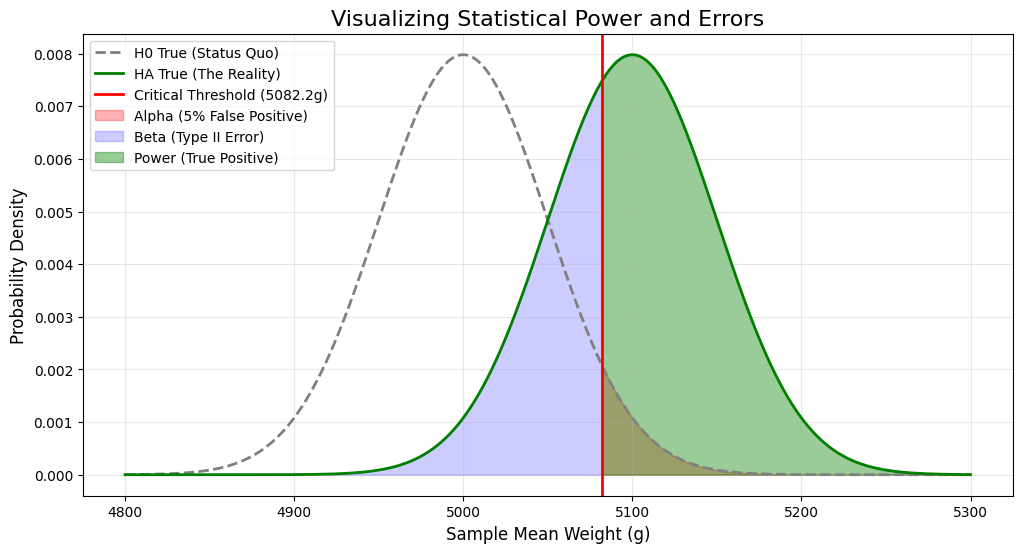

In [43]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. THE SETUP
mu_0 = 5000       # H0 Center
mu_a = 5100       # HA Center
sigma = 500
n = 100
alpha = 0.05

se = sigma / np.sqrt(n) # Standard Error (Noise)

# 2. CALCULATE THE TRAP (Critical Value)
z_critical = stats.norm.ppf(1 - alpha)
x_critical = mu_0 + (z_critical * se)

# 3. SET UP THE PLOT AXIS (from 4800 to 5300)
x = np.linspace(4800, 5300, 1000)

# Calculate the Y-values (bell curve heights) for both realities
y_h0 = stats.norm.pdf(x, mu_0, se)
y_ha = stats.norm.pdf(x, mu_a, se)

# 4. DRAW THE PLOT
plt.figure(figsize=(12, 6))

# Plot the two bell curves
plt.plot(x, y_h0, color='gray', linestyle='dashed', linewidth=2, label='H0 True (Status Quo)')
plt.plot(x, y_ha, color='green', linewidth=2, label='HA True (The Reality)')

# Draw the Critical Threshold (The Trap)
plt.axvline(x_critical, color='red', linestyle='solid', linewidth=2, label=f'Critical Threshold ({x_critical:.1f}g)')

# SHADING THE AREAS
# Alpha (Type I Error): Under H0, to the right of the trap
x_alpha = x[x > x_critical]
plt.fill_between(x_alpha, stats.norm.pdf(x_alpha, mu_0, se), color='red', alpha=0.3, label='Alpha (5% False Positive)')

# Beta (Type II Error): Under HA, to the left of the trap
x_beta = x[x < x_critical]
plt.fill_between(x_beta, stats.norm.pdf(x_beta, mu_a, se), color='blue', alpha=0.2, label='Beta (Type II Error)')

# Power: Under HA, to the right of the trap
x_power = x[x >= x_critical]
plt.fill_between(x_power, stats.norm.pdf(x_power, mu_a, se), color='green', alpha=0.4, label='Power (True Positive)')

# Formatting
plt.title('Visualizing Statistical Power and Errors', fontsize=16)
plt.xlabel('Sample Mean Weight (g)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()